## Qiskit simulations of QKD protocols with partial eavesdropping

### BB84

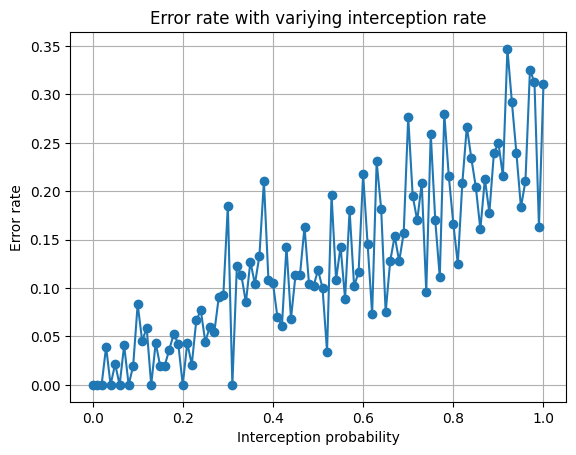

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile

# TODO: Add error correction and privacy aplification, and measure the
# impact of those.

def simulate_bb84(keylen, eve_probability):
    # initialize simulator
    simulator = AerSimulator()

    # generate bits and bases for Alice and Bob
    a_bits = np.random.randint(2, size=keylen)
    a_bases = np.random.choice(['+', 'x'], size=keylen)
    b_bases = np.random.choice(['+', 'x'], size=keylen)

    # Eve will randomly choose to measure the transmitted state in the 'x' basis
    e_bases = np.random.choice(['+', 'x'], size=keylen)

    # generate quantum state for transmission
    circuits = []
    for bit, base in zip(a_bits, a_bases):
        circ = QuantumCircuit(1, 1)
        if bit == 1:
            circ.x(0)
        if base == 'x':
            circ.h(0)
        circuits.append(circ)

    # simulate Eve's interception
    modified_circuits = []
    for circ, base in zip(circuits, e_bases):
        if not np.random.rand() < eve_probability:
            modified_circuits.append(circ)
            continue

        if base == 'x':
            circ.h(0)
        circ.measure(0, 0)
        tcirc = transpile(circ, simulator)
        result = simulator.run(tcirc, shots=1, memory=True).result()
        e_bit = int(result.get_memory()[0])
        
        new_circ = QuantumCircuit(1, 1)
        if e_bit:
            new_circ.x(0)
        if base == 'x':
            new_circ.h(0)
        modified_circuits.append(new_circ)

    # simulate Bob's measurements
    b_result = []
    for circ, base in zip(modified_circuits, b_bases):
        if base == 'x':
            circ.h(0)
        circ.measure(0, 0)

        tcirc = transpile(circ, simulator)
        result = simulator.run(tcirc, shots=1, memory=True).result()
        b_result.append(int(result.get_memory()[0]))

    # compare measurement bases
    matched = a_bases == b_bases
    if len(matched) < keylen//2:
        raise RuntimeError('Discrepancy between results too large. Key distribution terminated.')
    a_key = a_bits[matched]
    b_key = np.array(b_result)[matched]

    # estimate error
    errors = sum([1 for i in range(len(a_key)) if a_key[i] != b_key[i]])
    error_rate = errors / len(a_key)
    return error_rate

eve_probabilities = np.linspace(0, 1, 101)
error_rates = [simulate_bb84(100, p) for p in eve_probabilities]

plt.plot(eve_probabilities, error_rates, marker='o')
plt.xlabel('Interception probability')
plt.ylabel('Error rate')
plt.title('Error rate with variying interception rate')
plt.grid(True)
plt.show()

### EPR

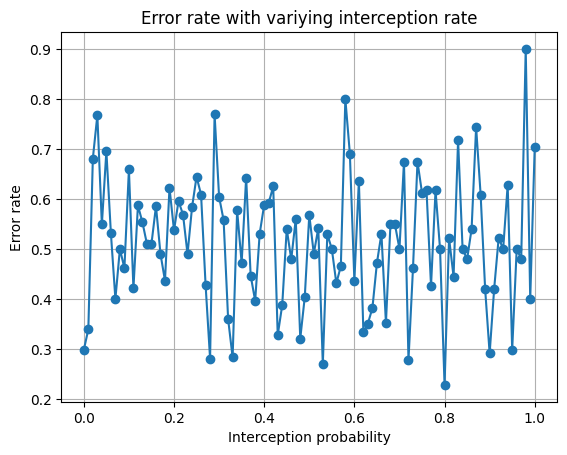

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile

def simulate_epr(keylen, eve_probability):
    # initialize simulator
    simulator = AerSimulator()

    # generate bases for Alice and Bob
    a_bases = np.random.choice(['z', 'x'], size=keylen)
    b_bases = np.random.choice(['z', 'x'], size=keylen)

    # Eve will randomly choose to measure the transmitted qubits in the 'x' basis
    e_bases = np.random.choice(['z', 'x'], size=keylen)

    # generate quantum state for transmission
    a_result = np.empty(keylen, dtype=int)
    b_result = np.empty(keylen, dtype=int)
    for a_base, b_base, e_base in zip(a_bases, b_bases, e_bases):
        circ = QuantumCircuit(2, 2)
        circ.h(0)
        circ.cx(0, 1)

        # Eve intercepts the transmission and acts as Bob would
        if not np.random.rand() < eve_probability:
            if e_base == 'x':
                circ.h(1)
            circ.measure(1, 1)

            tcirc = transpile(circ.copy(), simulator)
            job = simulator.run(tcirc, shots=1, memory=True)
            eve_bit = int(job.result().get_memory()[0][0])
            circ = QuantumCircuit(2, 2)
            if eve_bit == 1:
                circ.x(1)

        if a_base == 'x':
            circ.h(0)
        if b_base == 'x':
            circ.h(1)
        
        circ.measure(0, 0)  # Alice's measurement
        circ.measure(1, 1)  # Bob's measurement

        # tcirc = transpile(circ, simulator)
        result = simulator.run(circ, shots=1).result()
        measured_bits = list(result.get_counts(circ).keys())[0]
        np.append(b_result, int(measured_bits[0]))
        np.append(a_result, int(measured_bits[1]))
    
    matched_bases = a_bases == b_bases
    matched_result = a_result == b_result
    a_key = a_result[list(x==y for x,y in zip(matched_bases, matched_result))]
    errors = sum([1 for i in range(keylen) if matched_bases[i] and not matched_result[i]])
    error_rate = errors / len(a_key)

    return error_rate


eve_probabilities = np.linspace(0, 1, 101)
error_rates = [simulate_epr(100, p) for p in eve_probabilities]

plt.plot(eve_probabilities, error_rates, marker='o')
plt.xlabel('Interception probability')
plt.ylabel('Error rate')
plt.title('Error rate with variying interception rate')
plt.grid(True)
plt.show()